In [54]:
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [55]:
data  = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_classes=2, random_state=42)

In [56]:
X = data[0]
y = data[1]

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(f"coefficients: {model.coef_}, intercept: {model.intercept_}")

Accuracy: 0.95
coefficients: [[ 3.06127461 -0.68478105]], intercept: [0.23246397]


In [59]:
class SigmoidGradientDescent:

    def __init__(self, learning_rate=0.01, n_iter=1000):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.weights = None
        self.intercept = None

    def sigmoidFunction(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X_train, y_train):

        X_train = np.insert(X_train, 0, 1, axis=1)

        self.weights = np.zeros(X_train.shape[1])

        for _ in range(self.n_iter):

            z = np.dot(X_train, self.weights)

            y_pred = self.sigmoidFunction(z)

            gradient = -np.dot(X_train.T, (y_pred - y_train)) / X_train.shape[0]

            self.weights += self.learning_rate * gradient

        self.intercept = self.weights[0]
        self.weights = self.weights[1:]

    def predict(self, X_test):

        z = np.dot(X_test, self.weights) + self.intercept

        y_hat = self.sigmoidFunction(z)

        return np.where(y_hat >= 0.5, 1, 0)

In [66]:
sigmoid_gradient_descent_model = SigmoidGradientDescent(learning_rate=0.1, n_iter=1000)
sigmoid_gradient_descent_model.fit(X_train, y_train)
y_pred = sigmoid_gradient_descent_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(f"coefficients: {sigmoid_gradient_descent_model.weights}, intercept: {sigmoid_gradient_descent_model.intercept}")

Accuracy: 0.95
coefficients: [ 4.57275219 -1.13005281], intercept: 0.29075219564231897


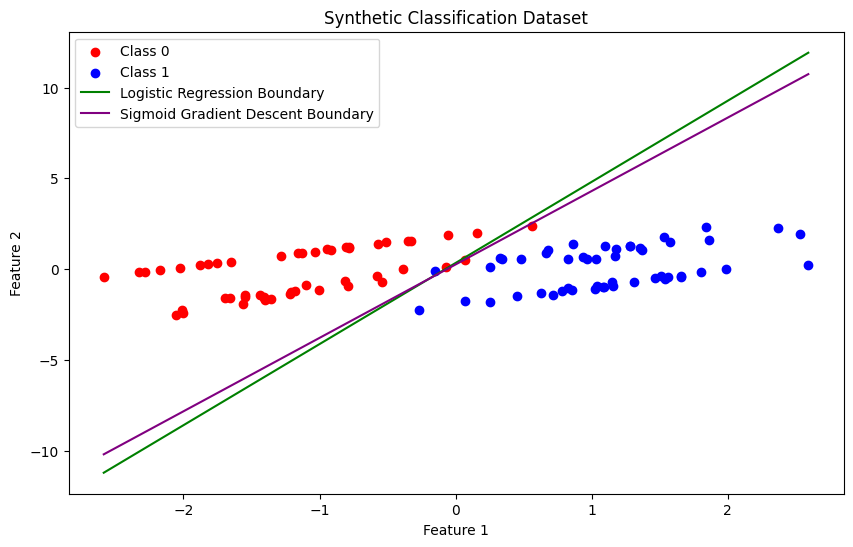

In [67]:
plt.figure(figsize=(10, 6))

# scatter points
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

# logistic regression decision boundary
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = -(model.coef_[0][0] * x1 + model.intercept_[0]) / model.coef_[0][1]
plt.plot(x1, x2, color='green', label='Logistic Regression Boundary')

# perceptron decision boundary
# x2_perceptron = -(new_model.weights[0] * x1 + new_model.intercept) / new_model.weights[1]
# plt.plot(x1, x2_perceptron, color='orange', label='Perceptron Boundary')

# perceptron with sigmoid decision boundary
# x2_perceptron_sigmoid = -(perceptron_with_sigmoid_model.weights[0] * x1 + perceptron_with_sigmoid_model.intercept) / perceptron_with_sigmoid_model.weights[1]
# plt.plot(x1, x2_perceptron_sigmoid, color='cyan', label='Perceptron with Sigmoid Boundary')

# sigmoid gradient descent decision boundary
x2_sigmoid_gradient_descent = -(sigmoid_gradient_descent_model.weights[0] * x1 + sigmoid_gradient_descent_model.intercept) / sigmoid_gradient_descent_model.weights[1]
plt.plot(x1, x2_sigmoid_gradient_descent, color='purple', label='Sigmoid Gradient Descent Boundary')

plt.title('Synthetic Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()